# **1. Install required libraries for NLP model training**

In [1]:
pip install transformers datasets==2.14.5 huggingface_hub

INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 19.4

In [2]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=f0d7c895bf6036af0ca366ed8bced70ab8dcb923d7f257ce5356213bb5483356
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [3]:
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import classification_report, f1_score

# **2.Data preparation pipeline**

In [4]:
dataset = load_dataset("languidsheep/bc5cdr")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [5]:
label_list = [
    "O",
    "B-Chemical",
    "B-Disease",
    "I-Disease",
    "I-Chemical"
]

id2label = {i: l for i, l in enumerate(label_list)}
label2id = {l: i for i, l in enumerate(label_list)}

In [6]:
model_name = "dmis-lab/biobert-base-cased-v1.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [7]:
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(
        example["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    word_ids = tokenized_inputs.word_ids()

    previous_word_idx = None
    label_ids = []

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(example["tags"][word_idx])
        else:
            label_ids.append(-100)

        previous_word_idx = word_idx

    tokenized_inputs["labels"] = label_ids
    return tokenized_inputs

In [8]:
tokenized_datasets = dataset.map(
    tokenize_and_align_labels,
    batched=False
)

Map:   0%|          | 0/5228 [00:00<?, ? examples/s]

Map:   0%|          | 0/5330 [00:00<?, ? examples/s]

Map:   0%|          | 0/5865 [00:00<?, ? examples/s]

# **3.Model training pipeline**

In [9]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
training_args = TrainingArguments(
    output_dir="./biobert-ner",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [11]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, label in zip(predictions, labels):
        curr_preds = []
        curr_labels = []

        for p_, l_ in zip(pred, label):
            if l_ != -100:
                curr_preds.append(id2label[p_])
                curr_labels.append(id2label[l_])

        true_predictions.append(curr_preds)
        true_labels.append(curr_labels)

    return {
        "f1": f1_score(true_labels, true_predictions)
    }

In [12]:
data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipykernel_19253/795571272.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# **4.Model evaluation and results**

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1
1,No log,0.077428,0.866574
2,0.105500,0.075656,0.879796
3,0.105500,0.092875,0.875569
4,0.028000,0.102739,0.883208
5,0.009700,0.109260,0.885022


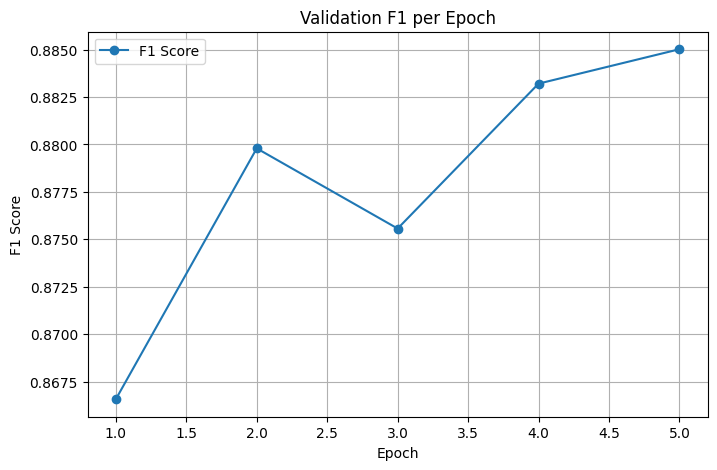

In [13]:
trainer.train()

log_history = trainer.state.log_history

import matplotlib.pyplot as plt

# ===== Training Loss =====
train_loss = [x["loss"] for x in log_history if "loss" in x]

# ===== Eval F1 =====
eval_f1 = [x["eval_f1"] for x in log_history if "eval_f1" in x]
epochs = [x["epoch"] for x in log_history if "eval_f1" in x]

# ===== Plot =====
plt.figure(figsize=(8,5))

plt.plot(epochs, eval_f1, marker='o', label="F1 Score")
plt.title("Validation F1 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid()
plt.legend()

plt.show()

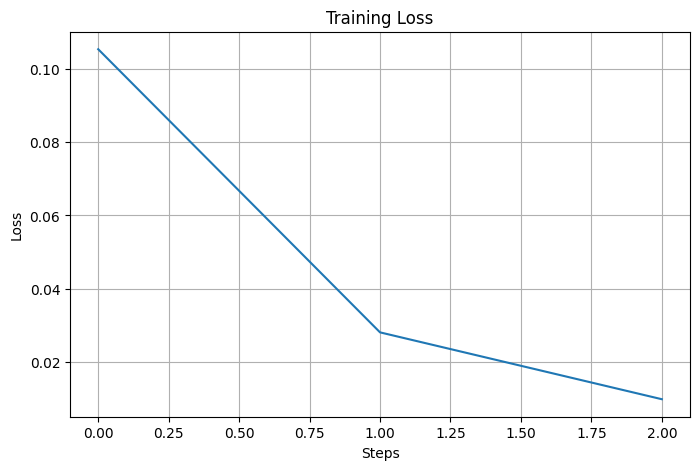

In [17]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(8,5))

plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid()

plt.show()

In [14]:
from seqeval.metrics import classification_report

predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions, axis=2)

true_labels = [
    [label_list[l] for l in label if l != -100]
    for label in labels
]

true_preds = [
    [label_list[p] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels)
]

print(classification_report(true_labels, true_preds))

              precision    recall  f1-score   support

    Chemical       0.92      0.93      0.92      5374
     Disease       0.80      0.86      0.83      4415

   micro avg       0.86      0.90      0.88      9789
   macro avg       0.86      0.89      0.87      9789
weighted avg       0.86      0.90      0.88      9789



In [15]:
trainer.save_model("./best-biobert-ner")
tokenizer.save_pretrained("./best-biobert-ner")

('./best-biobert-ner/tokenizer_config.json',
 './best-biobert-ner/special_tokens_map.json',
 './best-biobert-ner/vocab.txt',
 './best-biobert-ner/added_tokens.json',
 './best-biobert-ner/tokenizer.json')

# **5.Generate predictions on test data**

In [16]:
import json
import numpy as np

predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions, axis=2)

results = []

for i in range(len(preds)):
    tokens = tokenized_datasets["test"][i]["tokens"]

    gold = labels[i]
    pred = preds[i]

    gold_labels = []
    pred_labels = []

    for p, l in zip(pred, gold):
        if l != -100:
            gold_labels.append(label_list[l])
            pred_labels.append(label_list[p])

    results.append({
        "pmid": str(i),
        "tokens": tokens,
        "gold_labels": gold_labels,
        "pred_labels": pred_labels
    })

with open("biobert_predictions.json", "w") as f:
    json.dump(results, f, indent=2)